In [11]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [12]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control =  ['AE_267','AO_273','AE_287','AE_312']

all_animals = np.concatenate([post_opto, post_control])

In [4]:
df = pd.read_csv('../../Source Data Files/Figure 3k.csv')

In [5]:
df

,Unnamed: 0,animal,start nontarget go rate,end nontarget go rate,condition
0,0,BS_86,69.497319,79.106690,opto
1,1,BS_119,67.241050,92.852552,opto
2,2,BS_123,63.712979,85.033725,opto
3,3,BS_128,76.934697,64.650280,opto
4,4,BS_131,58.056781,84.938591,opto
5,5,BS_163,74.458246,85.793276,opto
6,6,BS_174,86.453983,97.632204,opto
7,7,AE_267,83.553267,24.255952,control
8,8,AO_273,81.776047,54.615385,control
9,9,AE_287,89.241692,39.067669,control


In [6]:
early_control_falarms = []
early_opsin_falarms = []
control_falarms = []
opsin_falarms = []

for row in df.iloc:
    early = row['start nontarget go rate']
    end = row['end nontarget go rate']
    if row['condition'] == 'opto':
        early_opsin_falarms.append(early)
        opsin_falarms.append(end)
    elif row['condition'] == 'control':
        early_control_falarms.append(early)
        control_falarms.append(end)

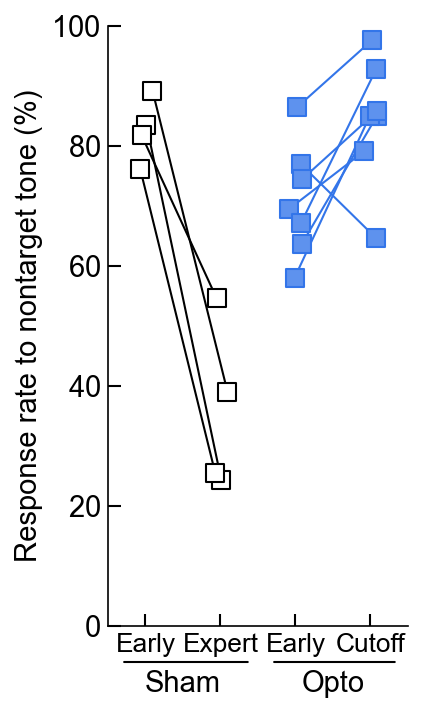

In [9]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(2, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25
meanwidth = 0.25

################################################################################################################
sz=75

control_data_early = early_control_falarms
opsin_data_early = early_opsin_falarms
control_data_cutoff = control_falarms
opsin_data_cutoff = opsin_falarms

control_X = np.random.uniform(-0.1,0.1,size=len(control_data_cutoff))
opsin_X = np.random.uniform(-0.1,0.1,size=len(opsin_data_cutoff))

X = control_X
Y = control_data_early
ax.scatter(X,Y,ec='k',fc='white',s=sz,marker='s')
X = control_X+1
Y = control_data_cutoff
ax.scatter(X,Y,ec='k',fc='white',s=sz,marker='s')
ax.plot([control_X,control_X+1],[control_data_early,control_data_cutoff],zorder=-10,c='k',lw=1)

X = opsin_X+2
Y = opsin_data_early
ax.scatter(X,Y,ec=LASER_COLOR,fc=LIGHT_LASER,s=sz,marker='s')

X = opsin_X+3
Y = opsin_data_cutoff
ax.scatter(X,Y,ec=LASER_COLOR,fc=LIGHT_LASER,s=sz,marker='s')
ax.plot([opsin_X+2,opsin_X+3],[opsin_data_early,opsin_data_cutoff],zorder=-10,c=LASER_COLOR,lw=1)

################################################################################################################

labels = ['Sham','Opto']

ax.set_ylim([0,1])
ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax.set_yticks([100*d for d in [0,0.2,0.4,0.6,0.8,1]])
ylab = ax.set_ylabel('Response rate to nontarget tone (%)')

ax.set_xlim(-0.5,3.5)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Early','Expert','Early','Cutoff'])

xtick_pos_pre = 0.5
xtick_pos_post = 2.5
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Sham', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Opto', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.04, -stdyfrac), xycoords='axes fraction', xytext=(0.48, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.54, -stdyfrac), xycoords='axes fraction', xytext=(0.97, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

artists = [ylab,t1,t2]
# fig.savefig(os.path.join('..','..','Figures','Figure 3k.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [10]:
X,Y = ilep.paired_rmnan(control_data_early,control_data_cutoff)
print(f"Control: {ttest_rel(X,Y).pvalue}")
X,Y = ilep.paired_rmnan(opsin_data_early,opsin_data_cutoff)
print(f"Opsin: {ttest_rel(X,Y).pvalue}")

Control: 0.0064903879220614006
Opsin: 0.0384282053643583
